In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\DATA SCIENCE Adi\2) Python\1) Aditya Code jupyter files\5 Projects\Purschase Case Study\purchase_data.csv")

In [3]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,NaN,NaN,7969.0


In [4]:
df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
263010,1004473,P00041942,M,36-45,1.0,B,3,0.0,5.0,18.0,NaN,3722.0
263011,1004473,P00115142,M,36-45,1.0,B,3,0.0,1.0,8.0,17.0,19253.0
263012,1004473,P00188442,M,36-45,1.0,B,3,0.0,5.0,7.0,NaN,3608.0
263013,1004473,P00119442,M,36-45,1.0,B,3,0.0,5.0,NaN,NaN,3604.0
263014,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isna().sum()

User_ID                            0
Product_ID                         1
Gender                             1
Age                                1
Occupation                         1
City_Category                      1
Stay_In_Current_City_Years         1
Marital_Status                     1
Product_Category_1                 1
Product_Category_2             81514
Product_Category_3            182433
Purchase                           1
dtype: int64

In [6]:
df.isnull().sum().sum()

np.int64(263956)

In [7]:
df.shape

(263015, 12)

We can clearly see in the dataset that people are purchasing products from 3 CATEGORIES, Some are purchasing from only 1, some 2 and others might purchase from all 3 Categories. How will I replace the NULL values over here? by simply replacing it with 0.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263014 non-null  object 
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          181501 non-null  float64
 10  Product_Category_3          80582 non-null   float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(6), int64(1), object(5)
memory usage: 24.1+ MB


In [9]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0', nan], dtype=object)

Machine Learning Models are not capable enough of understanding OBJECT data they only Understand Numeric Data

Now let's convert object data type into numeric data type

In [10]:
df['Stay_In_Current_City_Years'] = df['Stay_In_Current_City_Years'].replace("4+", 4)

In [11]:
df['Stay_In_Current_City_Years'].unique()

array(['2', 4, '3', '1', '0', nan], dtype=object)

In [12]:
df['Stay_In_Current_City_Years'].astype(int)

ValueError: cannot convert float NaN to integer

Since NaN is there, we cannot directly convert using astype command so we use the pd to numeric

In [13]:
df['Stay_In_Current_City_Years'] = pd.to_numeric(df['Stay_In_Current_City_Years'], errors = "coerce")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263015 entries, 0 to 263014
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263015 non-null  int64  
 1   Product_ID                  263014 non-null  object 
 2   Gender                      263014 non-null  object 
 3   Age                         263014 non-null  object 
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  object 
 6   Stay_In_Current_City_Years  263014 non-null  float64
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          181501 non-null  float64
 10  Product_Category_3          80582 non-null   float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(7), int64(1), object(4)
memory usage: 24.1+ MB


In [17]:
df.isnull().sum()

User_ID                            0
Product_ID                         1
Gender                             1
Age                                1
Occupation                         1
City_Category                      1
Stay_In_Current_City_Years         1
Marital_Status                     1
Product_Category_1                 1
Product_Category_2             81514
Product_Category_3            182433
Purchase                           1
dtype: int64

In [18]:
df.isnull().sum().sum()

np.int64(263956)

In [21]:
df['Product_Category_2'].fillna(0, inplace = True)
df['Product_Category_3'].fillna(0, inplace = True)

D:\Users\ipykernel_32012\1880039324.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Product_Category_2'].fillna(0, inplace = True)
D:\Users\ipykernel_32012\1880039324.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [24]:
df.isnull().sum()

User_ID                       0
Product_ID                    1
Gender                        1
Age                           1
Occupation                    1
City_Category                 1
Stay_In_Current_City_Years    1
Marital_Status                1
Product_Category_1            1
Product_Category_2            0
Product_Category_3            0
Purchase                      1
dtype: int64

In [25]:
df.dropna(inplace = True)

In [26]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category_1            0
Product_Category_2            0
Product_Category_3            0
Purchase                      0
dtype: int64

In [27]:
df.shape

(263014, 12)

In [29]:
df.head(4)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2.0,0.0,3.0,0.0,0.0,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2.0,0.0,1.0,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2.0,0.0,12.0,0.0,0.0,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2.0,0.0,12.0,14.0,0.0,1057.0


In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
le = LabelEncoder()

In [34]:
for i in df.columns:
    if df[i].dtype == "object":
        df[i] = le.fit_transform(df[i])

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  int64  
 2   Gender                      263014 non-null  int64  
 3   Age                         263014 non-null  int64  
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  int64  
 6   Stay_In_Current_City_Years  263014 non-null  float64
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 26.1 MB


In [37]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,647,0,0,10.0,0,2.0,0.0,3.0,0.0,0.0,8370.0
1,1000001,2304,0,0,10.0,0,2.0,0.0,1.0,6.0,14.0,15200.0
2,1000001,814,0,0,10.0,0,2.0,0.0,12.0,0.0,0.0,1422.0
3,1000001,790,0,0,10.0,0,2.0,0.0,12.0,14.0,0.0,1057.0
4,1000002,2657,1,6,16.0,2,4.0,0.0,8.0,0.0,0.0,7969.0


In [43]:
df['City_Category'].unique()

array([0, 2, 1])

# It was observed that the Average purchase made by men Of age 18 to 25 was 10,000, is it still the same?

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263014 entries, 0 to 263013
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     263014 non-null  int64  
 1   Product_ID                  263014 non-null  int64  
 2   Gender                      263014 non-null  int64  
 3   Age                         263014 non-null  int64  
 4   Occupation                  263014 non-null  float64
 5   City_Category               263014 non-null  int64  
 6   Stay_In_Current_City_Years  263014 non-null  float64
 7   Marital_Status              263014 non-null  float64
 8   Product_Category_1          263014 non-null  float64
 9   Product_Category_2          263014 non-null  float64
 10  Product_Category_3          263014 non-null  float64
 11  Purchase                    263014 non-null  float64
dtypes: float64(7), int64(5)
memory usage: 26.1 MB


In [47]:
new_data = df[(df['Age'] == 1) & (df['Gender'] == 1)]

In [48]:
new_data

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
97,1000021,2024,1,1,16.0,1,0.0,0.0,3.0,12.0,0.0,3055.0
98,1000022,3261,1,1,15.0,0,4.0,0.0,1.0,8.0,17.0,12099.0
99,1000022,1954,1,1,15.0,0,4.0,0.0,5.0,8.0,0.0,8797.0
100,1000022,1792,1,1,15.0,0,4.0,0.0,3.0,4.0,0.0,10681.0
101,1000022,1020,1,1,15.0,0,4.0,0.0,8.0,14.0,0.0,7801.0
...,...,...,...,...,...,...,...,...,...,...,...,...
262767,1004446,1311,1,1,18.0,1,1.0,1.0,1.0,2.0,0.0,15431.0
262951,1004465,2880,1,1,4.0,0,1.0,1.0,5.0,0.0,0.0,1763.0
262952,1004465,1296,1,1,4.0,0,1.0,1.0,2.0,3.0,4.0,3240.0
262953,1004465,2733,1,1,4.0,0,1.0,1.0,8.0,0.0,0.0,5832.0


In [50]:
new_data['Purchase'].mean() # Even from here we can see the mean is not equals to 10,000 but we need to prove it using statistical testing, so

np.float64(9440.512275679841)

In [59]:
sample = new_data.sample(3600, random_state = 50) # Random state will help you to save samples if you don't provide random state then after running the cell again you will get new sample You can set it to the value you want

In [60]:
sample

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
192406,1005730,2326,1,1,0.0,0,3.0,0.0,5.0,11.0,0.0,3476.0
111004,1005094,427,1,1,10.0,2,4.0,1.0,1.0,16.0,0.0,19040.0
2272,1000352,2611,1,1,4.0,0,0.0,0.0,6.0,8.0,0.0,16218.0
68665,1004495,1734,1,1,4.0,2,1.0,1.0,3.0,4.0,5.0,10684.0
174177,1002950,3085,1,1,0.0,2,4.0,0.0,5.0,8.0,0.0,1981.0
...,...,...,...,...,...,...,...,...,...,...,...,...
25068,1003850,2168,1,1,3.0,1,0.0,0.0,5.0,6.0,16.0,8836.0
234864,1000202,2694,1,1,4.0,0,3.0,0.0,1.0,8.0,0.0,15548.0
151388,1005394,1417,1,1,0.0,0,2.0,0.0,8.0,0.0,0.0,10059.0
152503,1005568,660,1,1,4.0,2,3.0,0.0,1.0,2.0,14.0,15782.0


In [61]:
# IMPORT THE TEST
from scipy.stats import ttest_1samp

In [62]:
avg_mean = 10000 #given in question

In [63]:
t_stat, p_value = ttest_1samp(sample['Purchase'], avg_mean) # Here we type average mean because we want to compare whether average mean and sample purchase mean are equal From here we would only require the P value and then we will compare
p_value

np.float64(4.7205063212345295e-14)

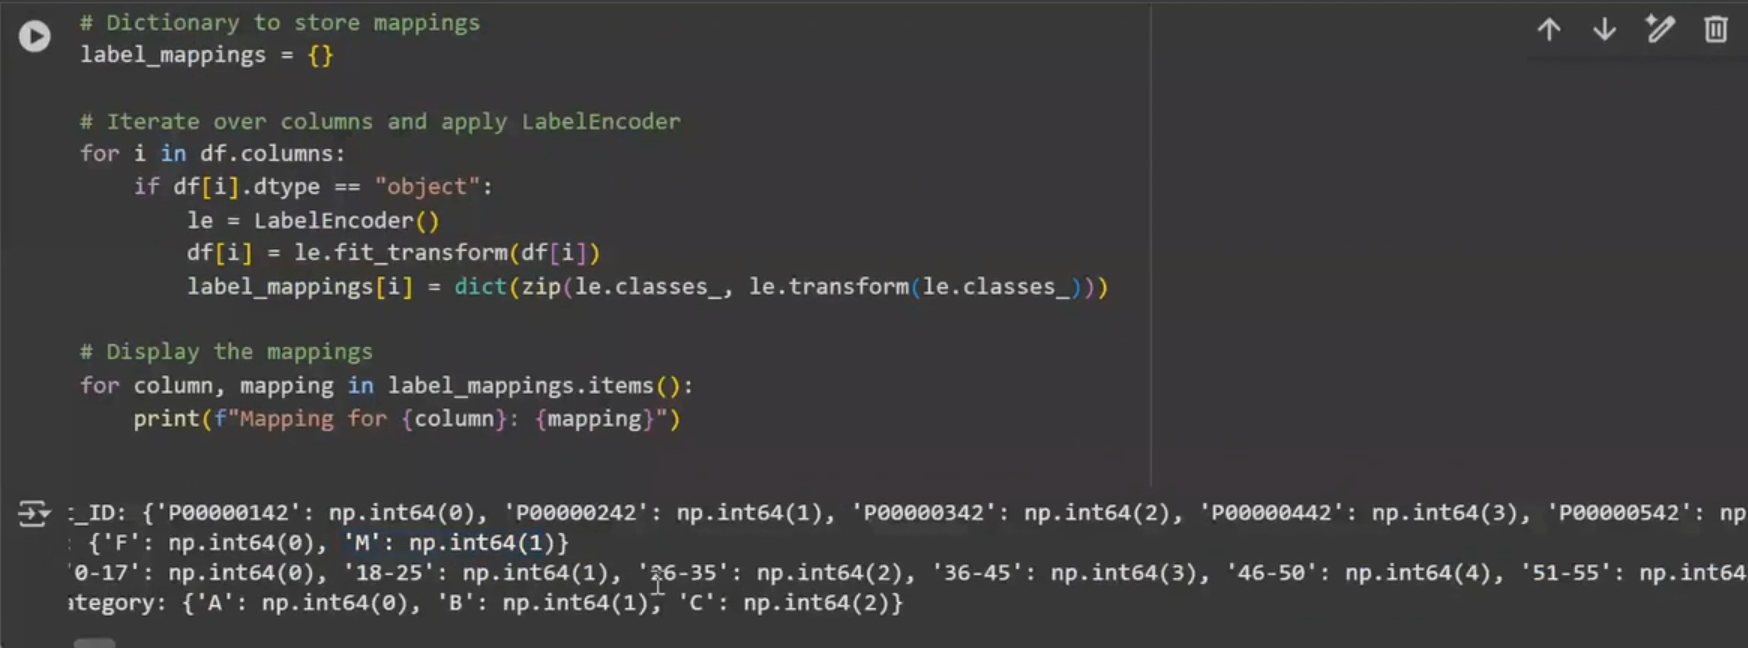

# Is the average purchase price of men and women of age 18 to 25 same?

In [82]:
dfm = df[(df['Gender'] == 1) & (df['Age'] == 1)] # Extracting only the male and female with age from 18 to 25
dfw = df[(df['Gender'] == 0) & (df['Age'] == 1)]

In [83]:
dfms = df.sample(1000, random_state = 1)  # Dividing them into samples so we can apply tests on them
dfws = df.sample(1000, random_state = 7)

In [84]:
dfms.Purchase.var()

24179188.279879864

In [85]:
dfws.Purchase.var()

26155852.358214233

In [86]:
dfms.Purchase.mean()

np.float64(9031.02)

In [87]:
dfws.Purchase.mean()  # Here we can clearly see that the means are different so we can reject the null hypothesis but we will still prove it with the test

np.float64(9325.512)

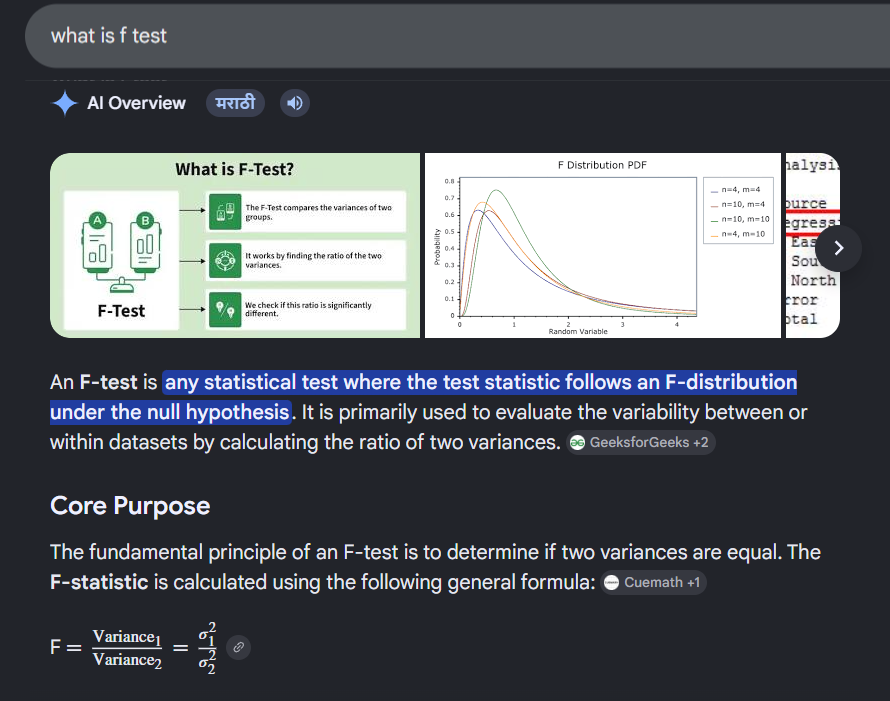
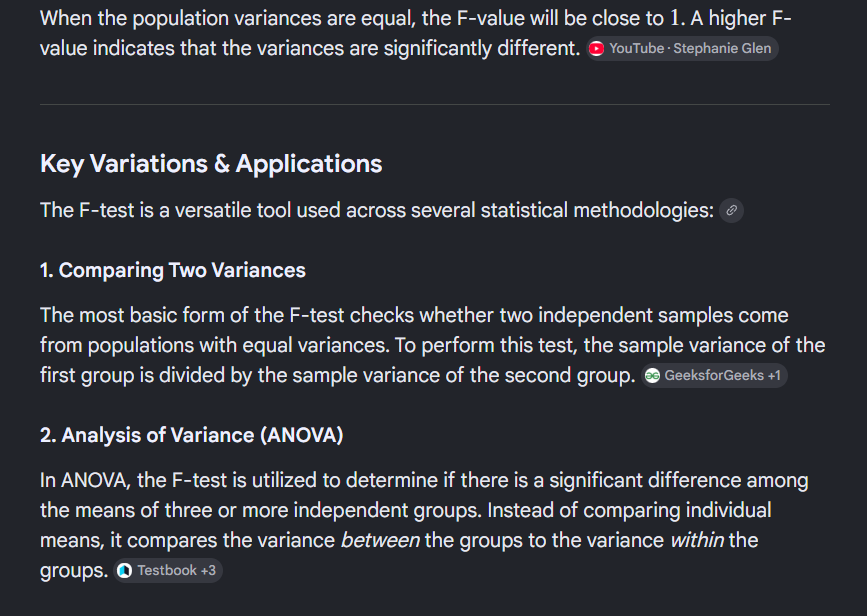
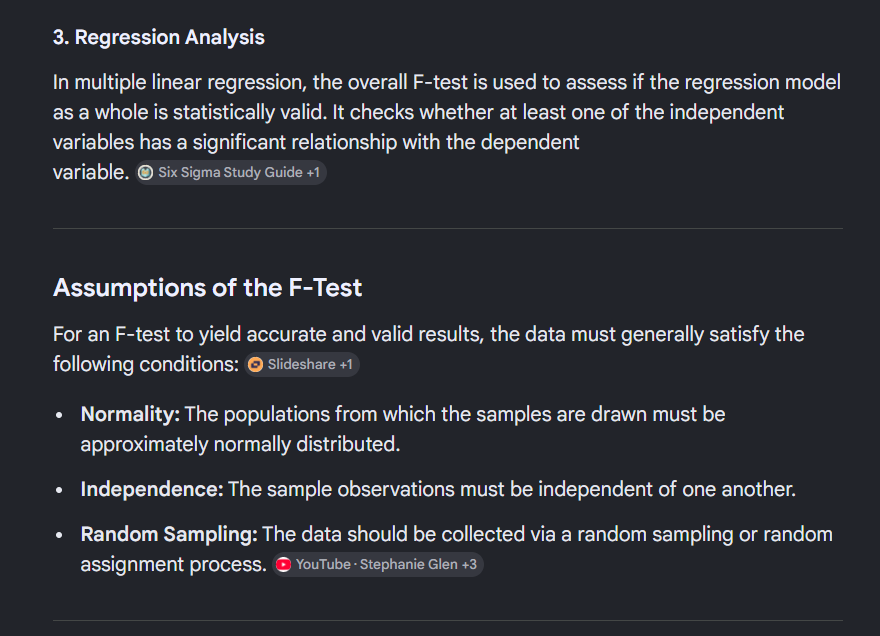
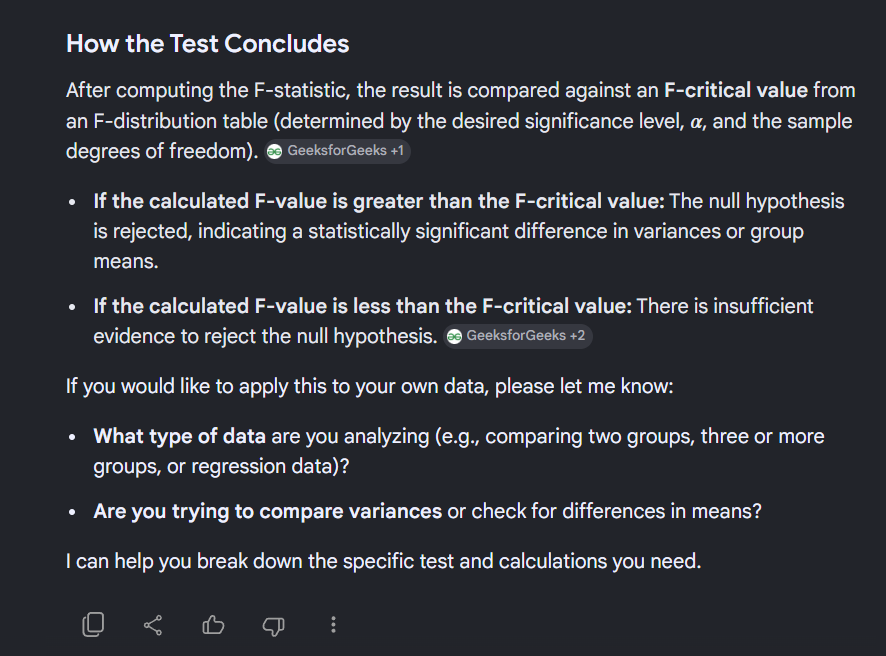

In [88]:
from scipy.stats import f
F = dfms.Purchase.mean()/dfws.Purchase.mean()
F

np.float64(0.9684208223634262)

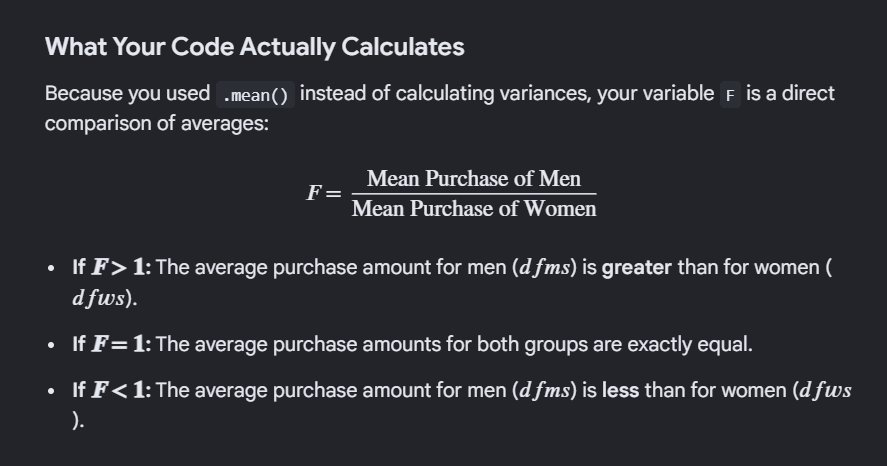

correct code for F test is

In [89]:
from scipy.stats import ttest_ind

# FIX: Take the 1000 samples directly from your filtered 18-25 dataframes
dfms = dfm.sample(1000, random_state=1)  # 1000 Random Men aged 18-25
dfws = dfw.sample(1000, random_state=7)  # 1000 Random Women aged 18-25

# Run an Independent Samples T-Test
# equal_var=False applies Welch's t-test (safer if variances differ)
t_stat, p_value = ttest_ind(dfms['Purchase'], dfws['Purchase'], equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")


T-statistic: 4.6387
P-value: 0.0000


In [90]:
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the Null Hypothesis.")
    print("Result: The average purchase price between men and women aged 18-25 is NOT the same.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis.")
    print("Result: There is no statistically significant evidence to say the averages are different.")


Conclusion: Reject the Null Hypothesis.
Result: The average purchase price between men and women aged 18-25 is NOT the same.


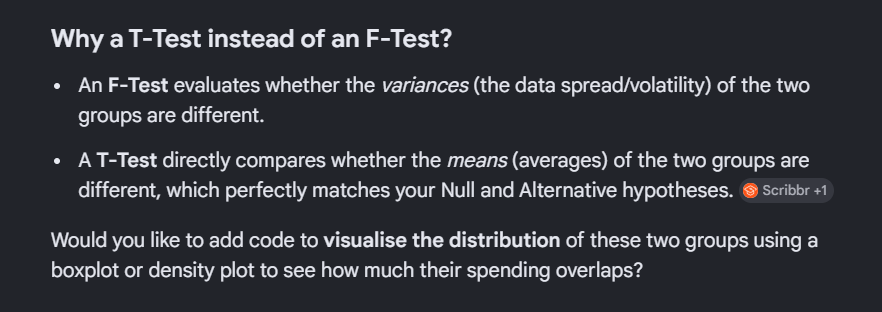

In [92]:
t_stats, p_value = ttest_1samp(dfms['Purchase'],dfws['Purchase'])
p_value

TypeError: ttest_1samp() got an unexpected keyword argument 'equal_var'

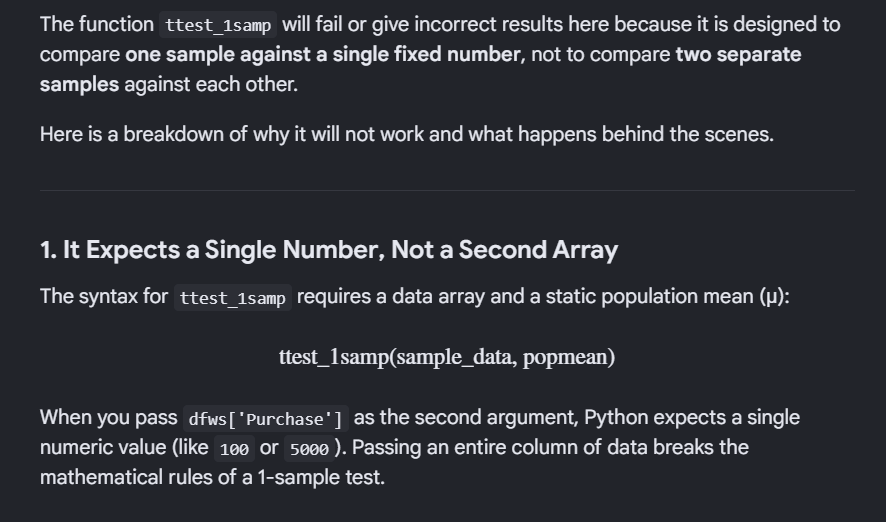
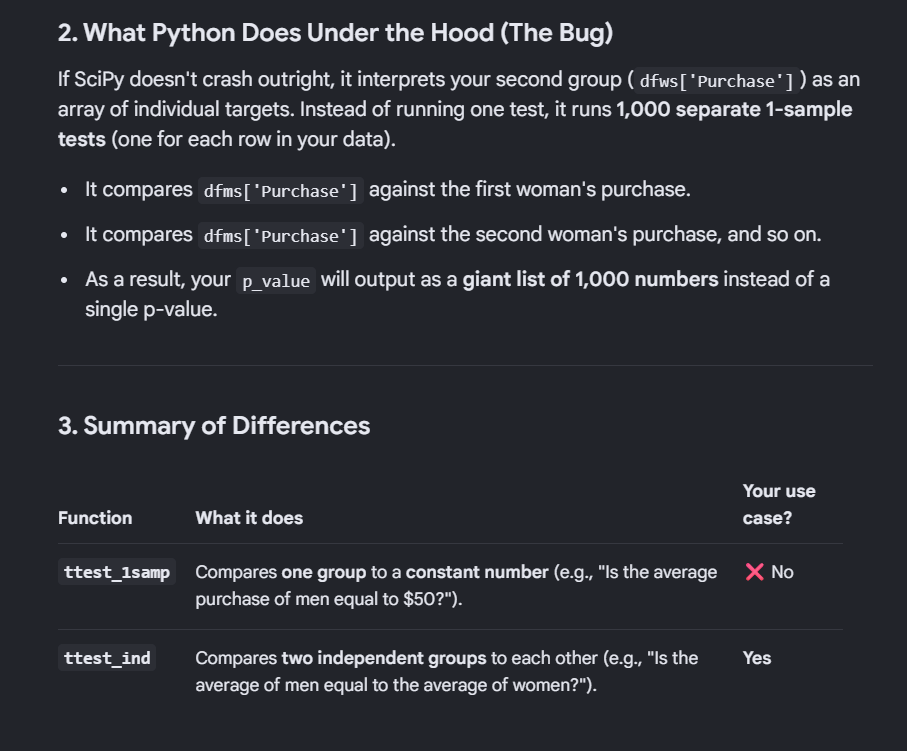
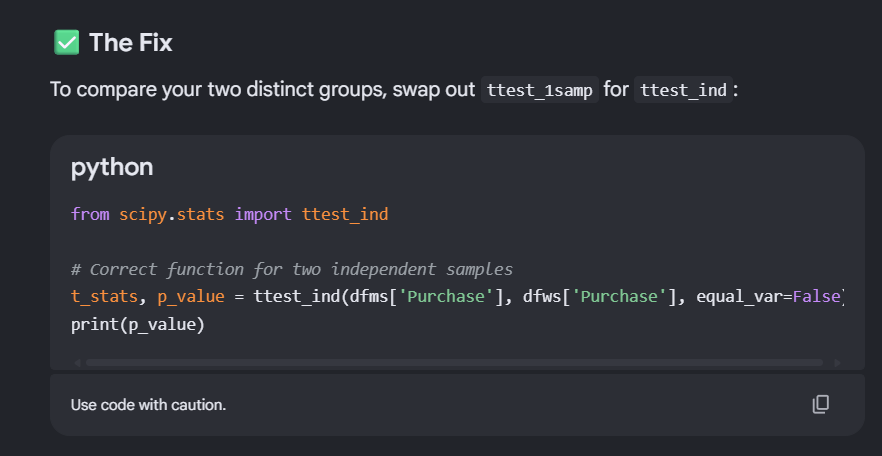